In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# notebook display settings
plt.rcParams['figure.figsize']  = (10, 5)
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size']         = 12
sns.set_palette('muted')

df = pd.read_csv('../outputs/cleaned_loans.csv')

# ensure correct types
df['issue_d']      = pd.to_datetime(df['issue_d'])
df['default_flag'] = df.get('default_flag', df.get('default')).astype(int)

print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"Default rate: {df['default_flag'].mean()*100:.1f}%")
df.head(3)

Loaded: 265,776 rows × 25 cols
Default rate: 20.1%


,id,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,...,dti,delinq_2yrs,fico_range_low,fico_range_high,open_acc,revol_util,total_acc,default,fico_mid,default_flag
0,68407277,3600.0,3600.0,36,13.99,123.03,C,C4,10+ years,MORTGAGE,...,5.91,0.0,675.0,679.0,7.0,29.7,13.0,0,677.0,0
1,68355089,24700.0,24700.0,36,11.99,820.28,C,C1,10+ years,MORTGAGE,...,16.06,1.0,715.0,719.0,22.0,19.2,38.0,0,717.0,0
2,68341763,20000.0,20000.0,60,10.78,432.66,B,B4,10+ years,MORTGAGE,...,10.78,0.0,695.0,699.0,6.0,56.2,18.0,0,697.0,0


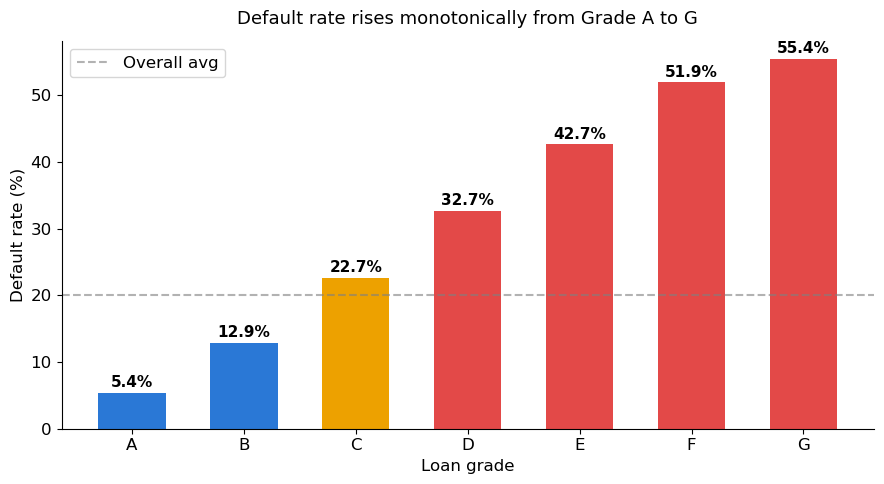

In [2]:
grade_stats = (
    df.groupby('grade')['default_flag']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'default_rate', 'count': 'loan_count'})
    .reset_index()
)
grade_stats['default_rate_pct'] = grade_stats['default_rate'] * 100

colors = ['#2a78d6' if r < 15 else '#eda100' if r < 25 else '#e34948'
          for r in grade_stats['default_rate_pct']]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(grade_stats['grade'], grade_stats['default_rate_pct'],
              color=colors, width=0.6)

for bar, val in zip(bars, grade_stats['default_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Loan grade')
ax.set_ylabel('Default rate (%)')
ax.set_title('Default rate rises monotonically from Grade A to G', fontsize=13, pad=12)
ax.axhline(df['default_flag'].mean()*100, color='gray', linestyle='--', alpha=0.6, label='Overall avg')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/chart1_grade_default.png', dpi=150)
plt.show()

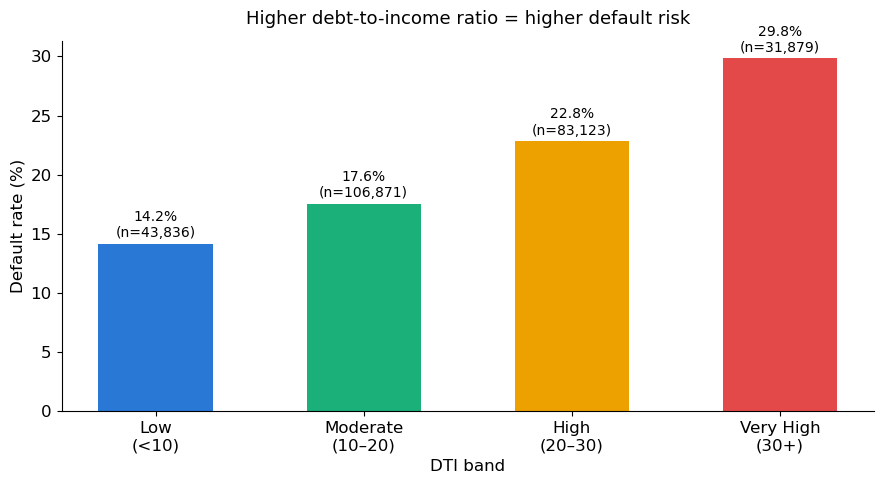

In [3]:
df['dti_band'] = pd.cut(
    df['dti'].dropna(),
    bins=[0, 10, 20, 30, 100],
    labels=['Low\n(<10)', 'Moderate\n(10–20)', 'High\n(20–30)', 'Very High\n(30+)']
)

dti_stats = (
    df.groupby('dti_band', observed=True)['default_flag']
    .agg(['mean', 'count'])
    .reset_index()
)
dti_stats['default_rate_pct'] = dti_stats['mean'] * 100

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(dti_stats['dti_band'].astype(str),
              dti_stats['default_rate_pct'],
              color=['#2a78d6', '#1baf7a', '#eda100', '#e34948'], width=0.55)

for bar, val, cnt in zip(bars, dti_stats['default_rate_pct'], dti_stats['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%\n(n={cnt:,})', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('DTI band')
ax.set_ylabel('Default rate (%)')
ax.set_title('Higher debt-to-income ratio = higher default risk', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('../outputs/chart2_dti_default.png', dpi=150)
plt.show()

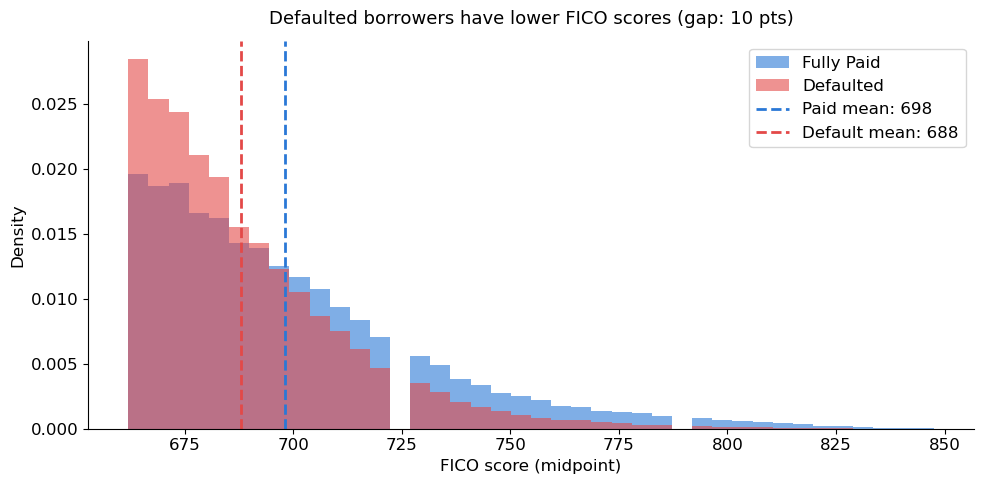

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df[df['default_flag']==0]['fico_mid'].dropna(),
        bins=40, alpha=0.6, color='#2a78d6', label='Fully Paid', density=True)
ax.hist(df[df['default_flag']==1]['fico_mid'].dropna(),
        bins=40, alpha=0.6, color='#e34948', label='Defaulted', density=True)

paid_mean    = df[df['default_flag']==0]['fico_mid'].mean()
default_mean = df[df['default_flag']==1]['fico_mid'].mean()

ax.axvline(paid_mean,    color='#2a78d6', linestyle='--', linewidth=2,
           label=f'Paid mean: {paid_mean:.0f}')
ax.axvline(default_mean, color='#e34948', linestyle='--', linewidth=2,
           label=f'Default mean: {default_mean:.0f}')

ax.set_xlabel('FICO score (midpoint)')
ax.set_ylabel('Density')
ax.set_title(f'Defaulted borrowers have lower FICO scores (gap: {paid_mean-default_mean:.0f} pts)',
             fontsize=13, pad=12)
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/chart3_fico_dist.png', dpi=150)
plt.show()

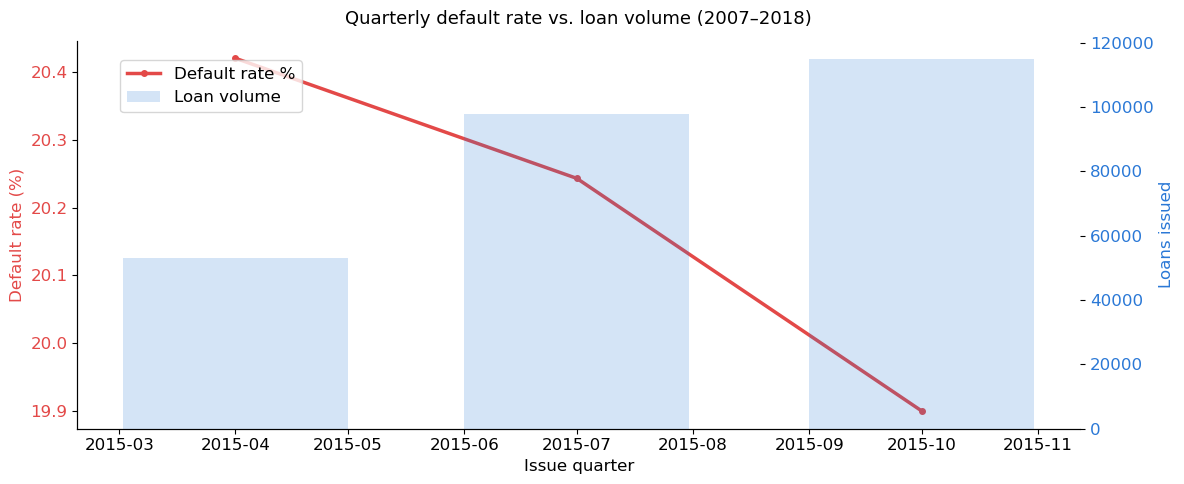

In [5]:
cohort = (
    df.groupby(df['issue_d'].dt.to_period('Q'))['default_flag']
    .agg(['mean', 'count'])
    .reset_index()
)
cohort['issue_d']         = cohort['issue_d'].dt.to_timestamp()
cohort['default_rate_pct'] = cohort['mean'] * 100

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(cohort['issue_d'], cohort['default_rate_pct'],
         color='#e34948', linewidth=2.5, marker='o', markersize=4, label='Default rate %')
ax1.set_ylabel('Default rate (%)', color='#e34948')
ax1.tick_params(axis='y', labelcolor='#e34948')

ax2 = ax1.twinx()
ax2.bar(cohort['issue_d'], cohort['count'],
        alpha=0.2, color='#2a78d6', width=60, label='Loan volume')
ax2.set_ylabel('Loans issued', color='#2a78d6')
ax2.tick_params(axis='y', labelcolor='#2a78d6')

ax1.set_xlabel('Issue quarter')
ax1.set_title('Quarterly default rate vs. loan volume (2007–2018)', fontsize=13, pad=12)
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.88))
plt.tight_layout()
plt.savefig('../outputs/chart4_trend.png', dpi=150)
plt.show()

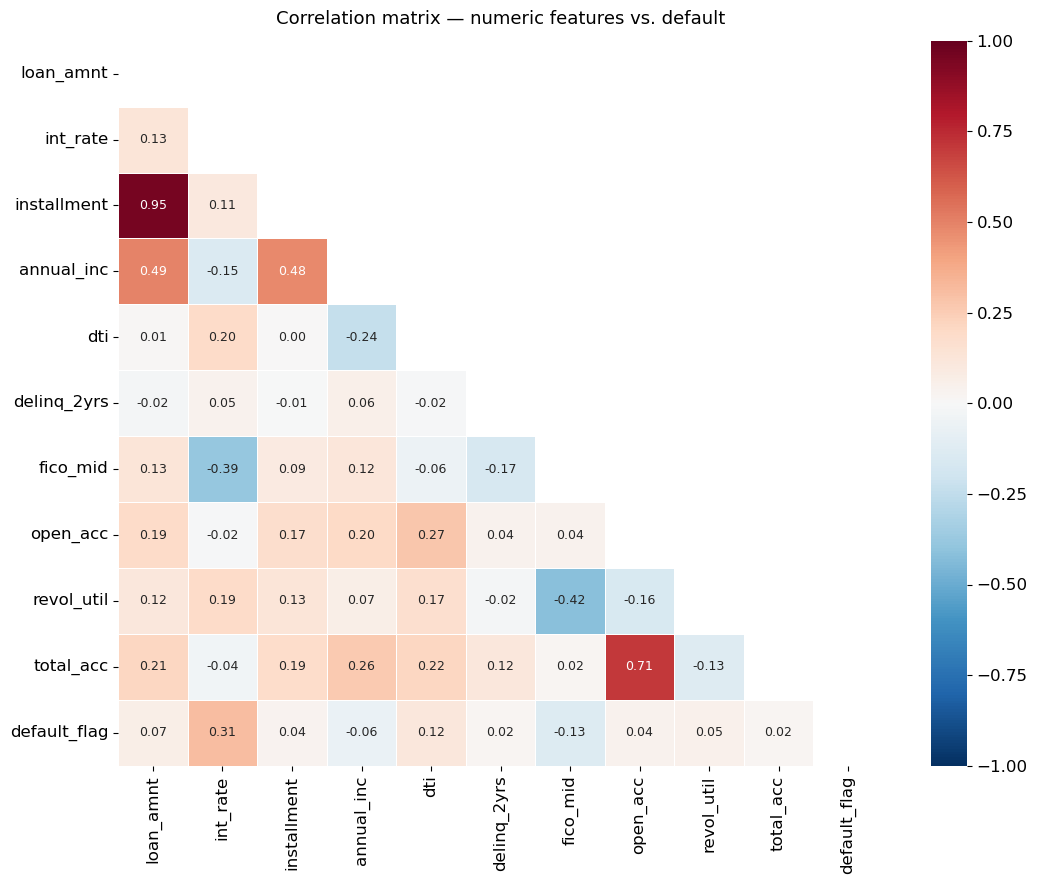


Top correlations with default_flag:
int_rate       0.305736
fico_mid      -0.134560
dti            0.115023
loan_amnt      0.067281
annual_inc    -0.064411
revol_util     0.053753
open_acc       0.042411
installment    0.035659
delinq_2yrs    0.017210
total_acc      0.016133
Name: default_flag, dtype: float64


In [6]:
num_cols = ['loan_amnt', 'int_rate', 'installment',
            'annual_inc', 'dti', 'delinq_2yrs',
            'fico_mid', 'open_acc', 'revol_util',
            'total_acc', 'default_flag']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 9}, ax=ax)

ax.set_title('Correlation matrix — numeric features vs. default', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('../outputs/chart5_correlation.png', dpi=150)
plt.show()

# print top correlations with default_flag
print("\nTop correlations with default_flag:")
print(corr['default_flag'].drop('default_flag').sort_values(key=abs, ascending=False))

In [7]:
# 1. monthly payment burden (installment as % of monthly income)
df['payment_to_income'] = df['installment'] / (df['annual_inc'] / 12 + 1)

# 2. credit utilisation ratio (open lines / total lines ever)
df['credit_util_ratio'] = df['open_acc'] / (df['total_acc'] + 1)

# 3. log income (reduces right-skew for modelling)
df['log_annual_inc'] = np.log1p(df['annual_inc'])

# 4. FICO band (categorical risk tier)
df['fico_band'] = pd.cut(df['fico_mid'],
    bins=[0, 650, 700, 750, 850],
    labels=['Poor (<650)', 'Fair (650–700)', 'Good (700–750)', 'Excellent (750+)']
)

# 5. delinquency flag (binary — any delinquency in past 2 years)
df['has_delinquency'] = (df['delinq_2yrs'] > 0).astype(int)

print("New features added:")
print(df[['payment_to_income', 'credit_util_ratio',
          'log_annual_inc', 'fico_band', 'has_delinquency']].head())

# save enriched dataset for Phase 4 and 5
df.to_csv('../outputs/featured_loans.csv', index=False)
print("\nSaved featured_loans.csv ✓")

New features added:
   payment_to_income  credit_util_ratio  log_annual_inc       fico_band  \
0           0.026837           0.500000       10.915107  Fair (650–700)   
1           0.151408           0.564103       11.082158  Good (700–750)   
2           0.082396           0.315789       11.050906  Fair (650–700)   
3           0.033309           0.333333       11.556311  Fair (650–700)   
4           0.142954           0.714286       10.434145  Fair (650–700)   

   has_delinquency  
0                0  
1                1  
2                0  
3                1  
4                0  

Saved featured_loans.csv ✓


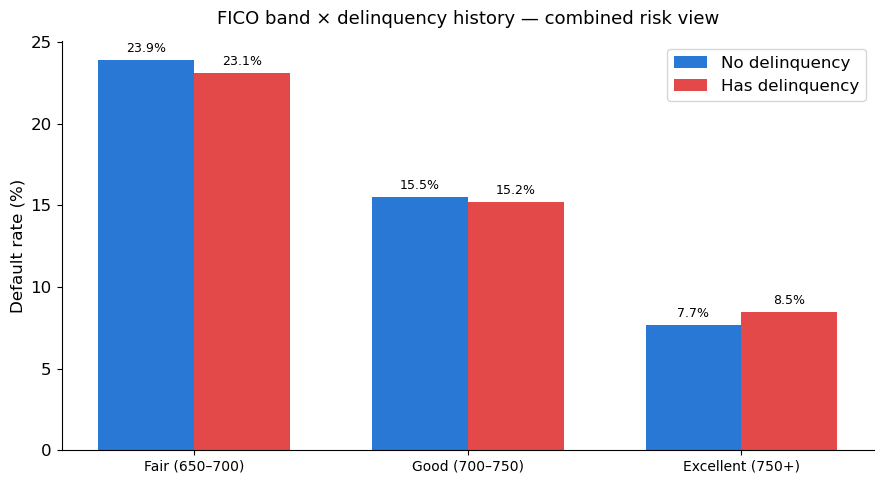

In [8]:
risk_matrix = (
    df.groupby(['fico_band', 'has_delinquency'], observed=True)['default_flag']
    .mean()
    .mul(100)
    .round(1)
    .unstack()
    .rename(columns={0: 'No delinquency', 1: 'Has delinquency'})
)

fig, ax = plt.subplots(figsize=(9, 5))
x      = np.arange(len(risk_matrix))
width  = 0.35

bars1 = ax.bar(x - width/2, risk_matrix['No delinquency'],
               width, label='No delinquency', color='#2a78d6')
bars2 = ax.bar(x + width/2, risk_matrix['Has delinquency'],
               width, label='Has delinquency', color='#e34948')

ax.set_xticks(x)
ax.set_xticklabels(risk_matrix.index, fontsize=10)
ax.set_ylabel('Default rate (%)')
ax.set_title('FICO band × delinquency history — combined risk view', fontsize=13, pad=12)
ax.legend()

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/chart6_risk_matrix.png', dpi=150)
plt.show()